## Compare Raw Habitat Metrics Between Spatial Scales

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statannotations.Annotator import Annotator
from scipy.stats import norm

#### I. Import and Assess Habitat Data
Import the dataframe of xDEM-generated habitat metrics generated in the  [03_Zonal_Statistics](03_Zonal_Statistics.ipynb) notebook.

In [2]:
df = pd.read_csv('habitat_metrics_summary_wide.csv')

Remove locations that we will not use in our ultimate analysis from the dataframe. 

In [3]:
disqualified_areas = ['TD', 'PC', 'LB']
df_cleaned = df[~df['Area'].isin(disqualified_areas)]

Distinguish relevant habitat metrics from metadata, and remove instances in habitat data where no habtiat metrics were generated (in this case, due to mistmach between the extent of the DEM and the grid cells during zonal statistics). 

In [4]:
# Differentiate between columns associated with metadata and habitat metrics  
metadata_columns = ['Grid_Cell_ID', 'Area', 'Full_Area', 'MPA_Status']
habitat_columns = [col for col in df_cleaned.columns if col not in metadata_columns]

# Remove rows that have no data in metrics specified by 'habitat_columns'
df_cleaned = df_cleaned.dropna(subset=habitat_columns, how='all')

In [5]:
df_cleaned

,Grid_Cell_ID,Full_Area,Area,MPA_Status,aspect_min,aspect_max,aspect_mean,aspect_std,aspect_median,curvature_min,...,terrain_ruggedness_index_min,terrain_ruggedness_index_max,terrain_ruggedness_index_mean,terrain_ruggedness_index_std,terrain_ruggedness_index_median,topographic_position_index_min,topographic_position_index_max,topographic_position_index_mean,topographic_position_index_std,topographic_position_index_median
0,AN01,Ano Nuevo,AN,REF,0.000608,359.999939,189.086755,104.148533,204.255234,-175.711914,...,0.014134,7.820934,0.927034,0.645765,0.776787,-1.815591,2.214877,-0.000039,0.169788,-0.011216
1,AN02,Ano Nuevo,AN,REF,0.000523,359.999756,185.132689,104.709714,200.048111,-158.436584,...,0.040059,8.464078,1.081520,0.635674,0.942224,-1.926841,1.956610,0.000311,0.189826,-0.009952
2,AN03,Ano Nuevo,AN,REF,0.000000,359.999542,189.599869,100.954922,215.612183,-109.372665,...,0.009995,8.280178,0.819195,0.746204,0.587218,-1.462498,1.740995,-0.000016,0.138957,-0.005646
3,AN04,Ano Nuevo,AN,REF,0.000000,359.999725,210.390805,98.236500,236.306763,-199.208252,...,0.000010,12.866380,0.688425,0.912303,0.379040,-2.200926,3.405399,-0.000156,0.160587,-0.001286
4,AN05,Ano Nuevo,AN,REF,0.000000,359.999817,207.752991,95.385900,223.670044,-101.696396,...,0.000000,7.459412,0.763163,0.961316,0.405691,-1.335721,1.534657,0.000054,0.170942,-0.001247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,SP16,Stewarts Point,SP,REF,0.000000,359.999969,197.976526,95.877258,210.511826,-362.000000,...,0.000000,13.672822,1.361574,1.129367,1.020147,-3.161247,3.217499,0.000179,0.276526,-0.019997
344,SP17,Stewarts Point,SP,REF,0.000000,359.999969,204.038652,82.386392,211.299500,-165.500061,...,0.024491,16.048851,1.173219,1.158922,0.809259,-2.216248,3.922503,-0.000139,0.244034,-0.008751
345,SP18,Stewarts Point,SP,REF,0.000000,359.999969,209.555229,72.810096,217.056473,-378.750000,...,0.009998,14.088155,1.234895,1.286282,0.805854,-3.968750,2.685000,-0.000085,0.249195,-0.005001
346,SP19,Stewarts Point,SP,REF,0.000000,359.999969,198.990243,87.490977,213.845535,-170.999908,...,0.014142,16.460730,0.966270,0.910154,0.710810,-2.228751,4.717500,0.000186,0.212020,-0.012497


#### II. Assess Normality for Selected Metrics

Before we analyze or visualize any of our data, let's subset it to make it more managable. 

Here, I am going to explore fractal dimension, topographic position index,  and rugosity. These habitat characteristics have come through in my literature review as important to fish distrubution, and they are uniquely clustered in the PCA we performed in the [04_Habitat_Covariance](04_Habitat_Covariance.ipynb) notebook. 

There are a few habitat metrics that require some thought in how we present them. Topographic position index, for example, ranges from -4 to 4 and represents where one pixel is relative to its neighbors. It is frequently used to distinguish between landforms based on their relative position to one another (e.g. peaks, valleys, plains). In this instance, the standard deviation of TPI is more useful for describing a landscape: a low standard deviation reveals that the landscape is more uniform, while high standard deviation value reveals that the landscape is varied in its highs and lows. 


In [19]:
complexity_metrics = ['slope_mean', 
                   'topographic_position_index_std', 
                   'profile_curvature_std',
                    'planform_curvature_std', 
                    'curvature_std',
                   'roughness_mean',
                   'rugosity_mean',
                   'terrain_ruggedness_index_mean',
                   'fractal_roughness_mean']

#### Habitat Metric Histograms
Assess for normality of each habtiat metric that I aim to incorporate into my pilot complexity proxy. 

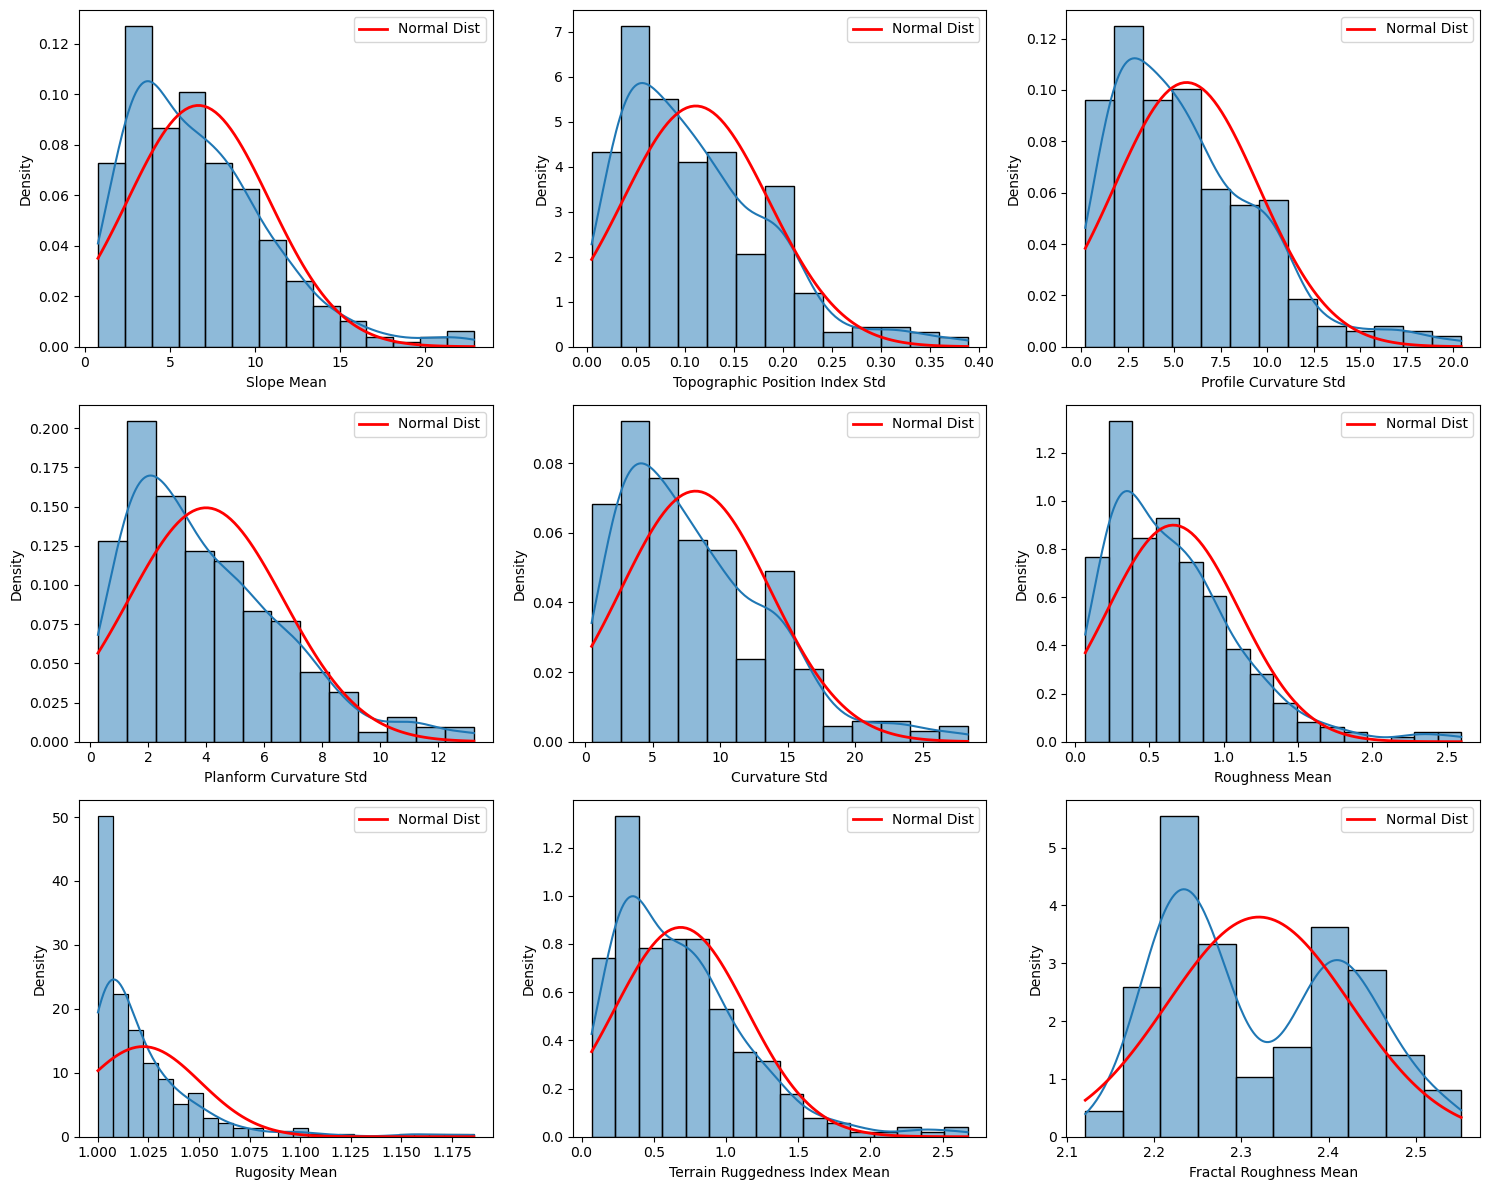

In [36]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))  
axes = axes.flatten()  # flatten to make indexing easier

for i, complexity_metric in enumerate(complexity_metrics):
    data = df_cleaned[complexity_metric].dropna()  # remove NaNs

    # Plot histogram
    sns.histplot(data, kde=True, stat="density", ax=axes[i],)

    # Overlay normal distribution
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    axes[i].plot(x, norm.pdf(x, mu, sigma), color='red', lw=2, label='Normal Dist')

    axes[i].set_xlabel(complexity_metric.replace("_", " ").title())
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()


#### Normalizing with Transformations
Let's try to normalize the data by log transforming it. This will be applicable only for some metrisc. For example, fractal roughness has a bimodal distribution, which cannot be normalized with a log transformation. 

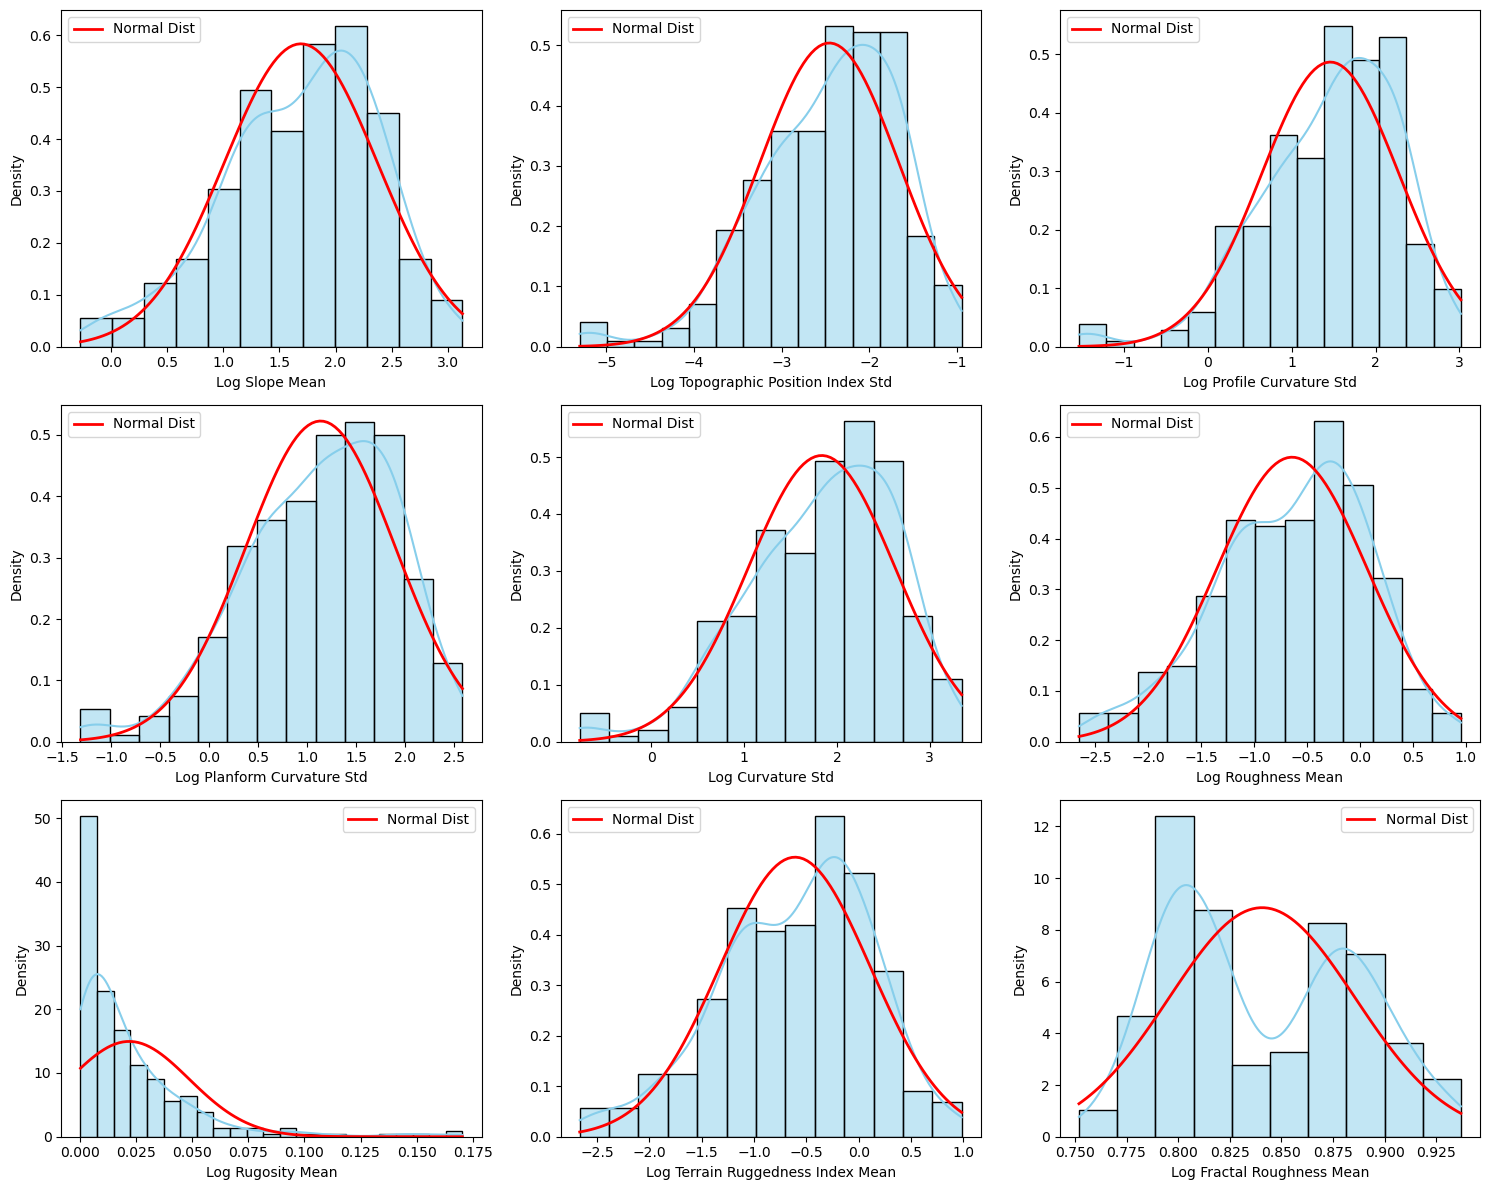

In [37]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))  
axes = axes.flatten()  # flatten to make indexing easier

for i, complexity_metric in enumerate(complexity_metrics):
    # Log-transform and drop NaNs or negative/zero values
    data = np.log(df_cleaned[complexity_metric][df_cleaned[complexity_metric] > 0].dropna())

    # Plot histogram with KDE
    sns.histplot(data, kde=True, stat="density", ax=axes[i], color='skyblue', edgecolor='black')

    # Overlay normal distribution
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    axes[i].plot(x, norm.pdf(x, mu, sigma), color='red', lw=2, label='Normal Dist')

    axes[i].set_xlabel('Log ' + complexity_metric.replace("_", " ").title())
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()


#### III. Analyze and Plot Differences in Habitat Metrics

##### A. Habitat Metrics Between MPA and REF Sites

Let's zoom in a little bit to check out how properly normalized habitat metrics varies by location across the coast. Let's establish whether mean our subset habitat metrics differ between locations. 

In [47]:
habitat_subset = ['slope_mean', 'topographic_position_index_std', 'roughness_mean']

C:\Users\FELAB\AppData\Local\Temp\ipykernel_11796\366388007.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="MPA_Status", y=y_col, order=order, palette=site_palette, ax=ax)
C:\Users\FELAB\AppData\Local\Temp\ipykernel_11796\366388007.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="MPA_Status", y=y_col, order=order, palette=site_palette, ax=ax)
C:\Users\FELAB\AppData\Local\Temp\ipykernel_11796\366388007.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x="MPA_Status", y=y_col

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

REF vs. MPA: Welch's t-test independent samples, P_val:7.604e-04 t=3.402e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

REF vs. MPA: Welch's t-test independent samples, P_val:1.083e-03 t=3.303e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

REF vs. MPA: Welch's t-test independent samples, P_val:8.926e-04 t=3.356e+00


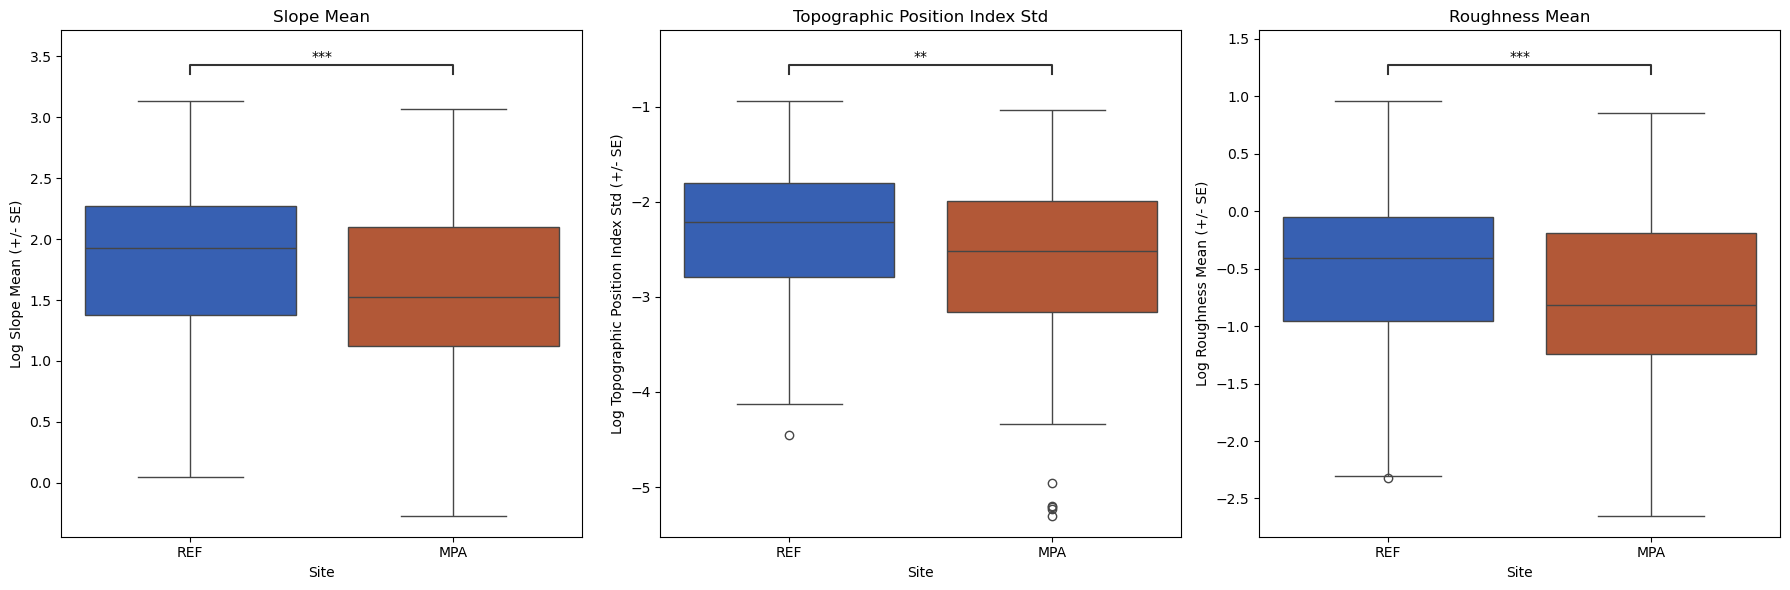

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  
order = ['REF', 'MPA']
site_palette = {'REF': '#2259C7', 'MPA': '#C74E22'}

for i, metric in enumerate(habitat_subset):
    y_col = f"log_{metric}"  # new column name
    # Log-transform, keep only positive values
    df_cleaned[y_col] = np.log(df_cleaned[metric].where(df_cleaned[metric] > 0))

    ax = axes[i]  # select the correct subplot
    sns.boxplot(data=df_cleaned, x="MPA_Status", y=y_col, order=order, palette=site_palette, ax=ax)

    # Annotate with statannotations
    pairs = [("REF", "MPA")]
    annotator = Annotator(ax, pairs, data=df_cleaned, x="MPA_Status", y=y_col, order=order)
    annotator.configure(test='t-test_welch', text_format='star', loc='inside', verbose=2)
    annotator.apply_and_annotate()

    ax.set_xlabel("Site")
    ax.set_ylabel(f"Log {metric.replace('_', ' ').title()} (+/- SE)")
    ax.set_title(metric.replace('_', ' ').title())

plt.tight_layout()
plt.show()


##### B. Habitat Metrics Between Locations

Let's zoom in a little bit to check out how PC1 of habitat metrics varies by location across the coast. Let's establish whether mean our subset habitat metrics differ between locations. 

Also, now that we've muddled with the original dataset, we will need to reorient the figures to a south to north orientation for ease of visualization. 

In [49]:
south_to_north = ['LJ', 'CP', 'PB', 'BL', 'PL', 'AN', 'FN', 'BH', 'SP', 'CM']

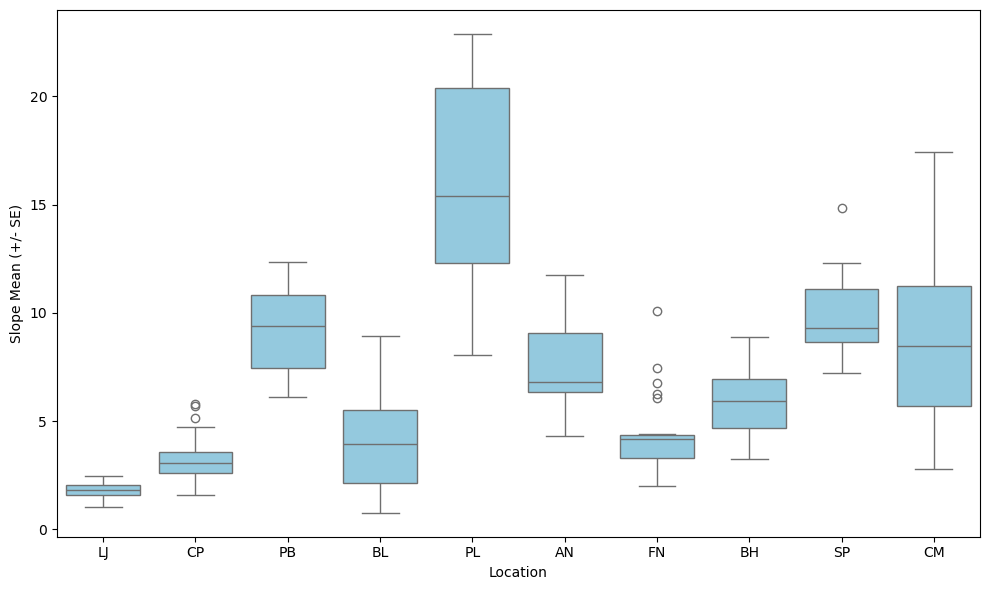

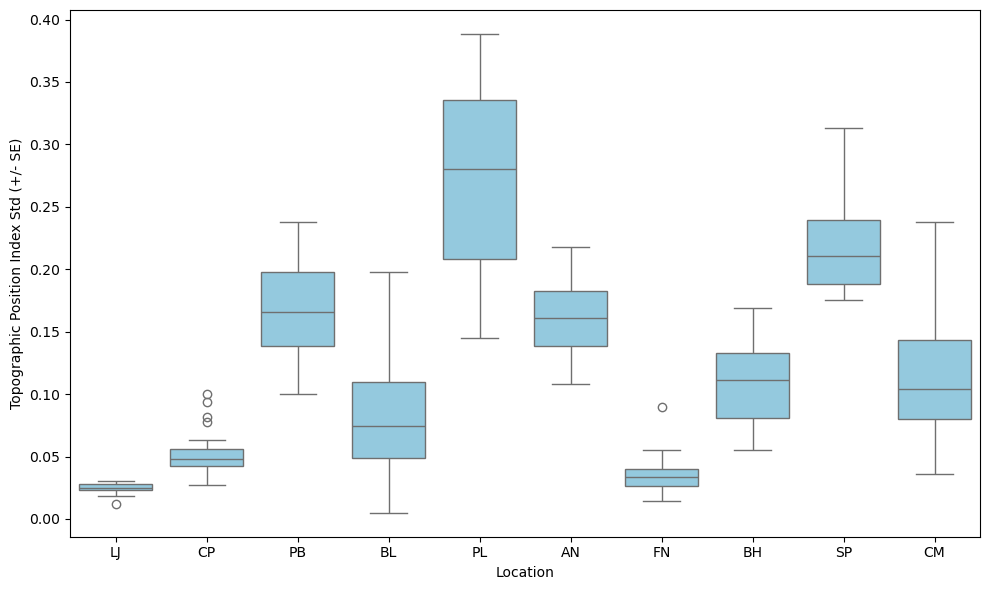

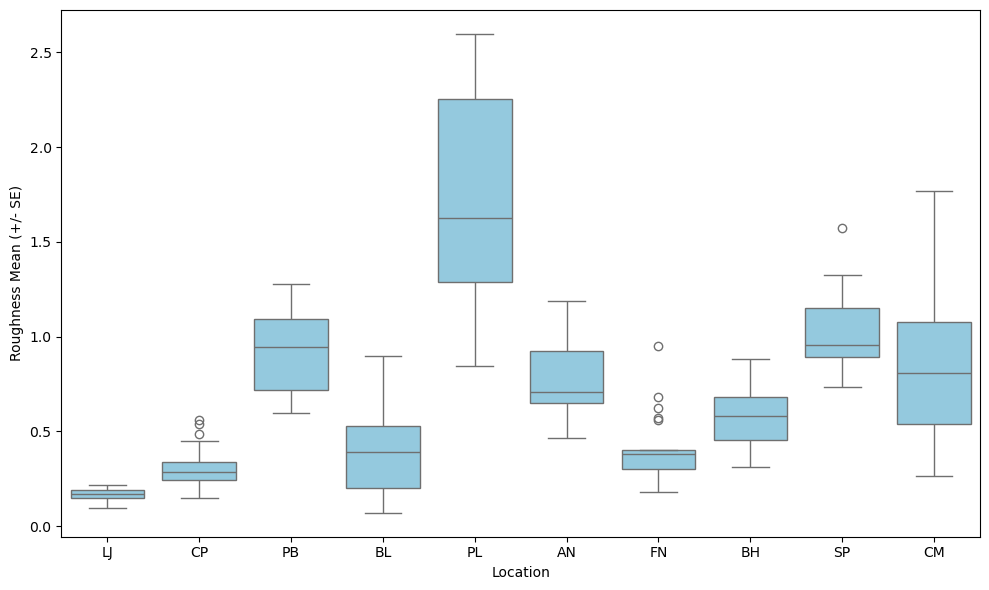

In [50]:
df_cleaned['Area'] = pd.Categorical(df_cleaned['Area'], categories=south_to_north, ordered=True)

for metric in habitat_subset: 

    plt.figure(figsize=(10, 6)) 
    metric_label = metric.replace('_', ' ').title()
    sns.boxplot(
        data=df_cleaned,
        x='Area',
        y=metric, 
        color = 'skyblue'
    )

    plt.xlabel("Location")
    plt.ylabel(f"{metric_label} (+/- SE)")
    plt.tight_layout()

    #output_path = f"WSN_Figures/{metric}_by_location.png"
    #plt.savefig(output_path, dpi=300, bbox_inches='tight')

    plt.show()

##### C. Habitat Metrics Between MPA and REF Sites within Locations

Finally, let's see how our subset habitat characteristics we generated using xDEM varies between MPA's and their reference sites within a given location. 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CM_REF vs. CM_MPA: Welch's t-test independent samples, P_val:1.466e-05 t=4.819e+00
FN_REF vs. FN_MPA: Welch's t-test independent samples, P_val:4.010e-02 t=2.347e+00


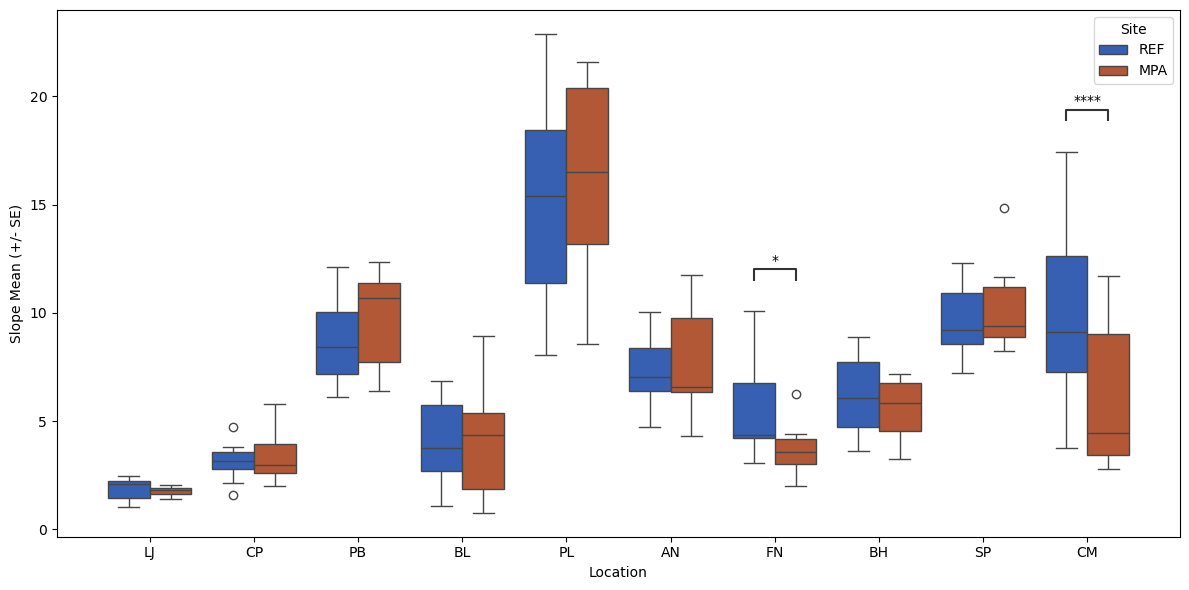

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CM_REF vs. CM_MPA: Welch's t-test independent samples, P_val:3.162e-06 t=5.057e+00
PB_REF vs. PB_MPA: Welch's t-test independent samples, P_val:9.993e-03 t=-2.849e+00


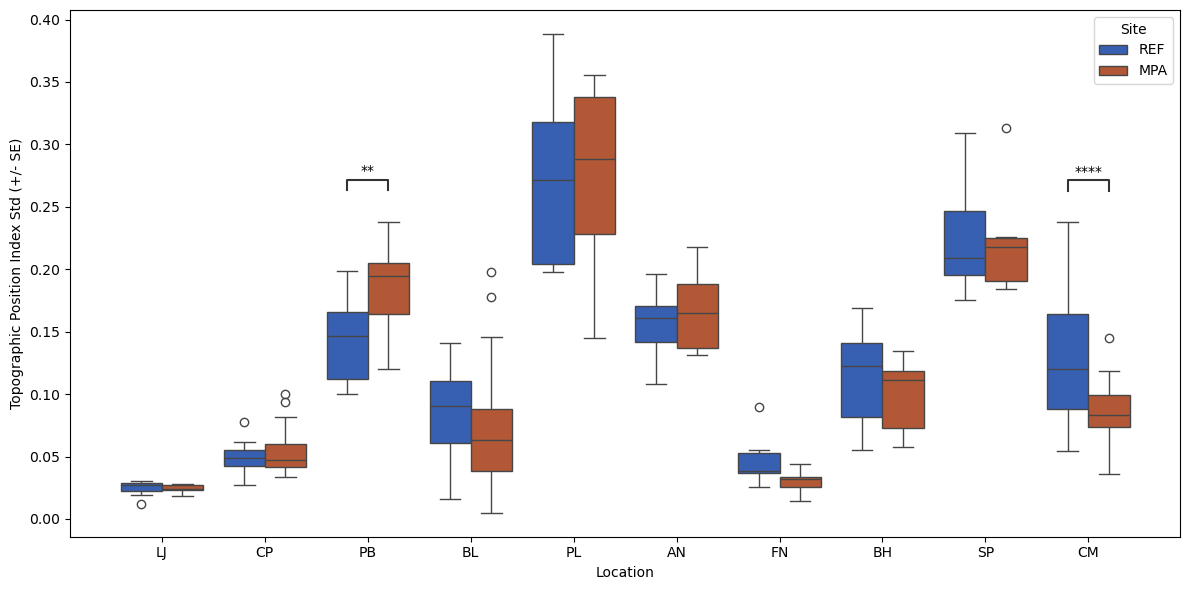

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CM_REF vs. CM_MPA: Welch's t-test independent samples, P_val:8.511e-06 t=4.928e+00
FN_REF vs. FN_MPA: Welch's t-test independent samples, P_val:4.157e-02 t=2.330e+00


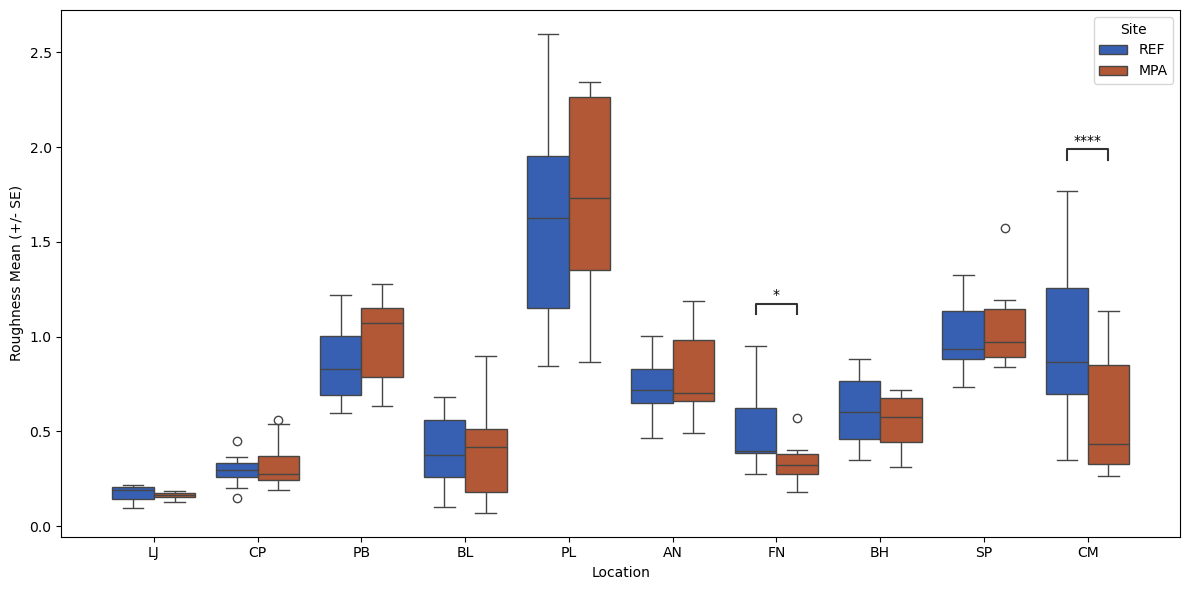

In [51]:
df_cleaned['Area'] = pd.Categorical(df_cleaned['Area'], categories=south_to_north, ordered=True)

for metric in habitat_subset: 
    
    x = 'Area'
    y = metric
    hue = 'MPA_Status'
    
    metric_label = metric.replace('_', ' ').title()
    
    site_palette = {
        'REF': '#2259C7',
        'MPA': '#C74E22'
    }

    order = south_to_north  # <-- use your predefined order here
    hue_order = ['REF', 'MPA']

    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(
        data=df_cleaned,
        x=x,
        y=y,
        hue=hue,
        order=order,
        hue_order=hue_order,
        palette=site_palette
    )

    box_pairs = [((area, 'REF'), (area, 'MPA')) for area in order]

    annotator = Annotator(ax, box_pairs, data=df_cleaned, x=x, y=y, hue=hue, order=order, hue_order=hue_order)
    annotator.configure(test='t-test_welch', text_format='star', loc='inside', verbose=2, hide_non_significant=True)
    annotator.apply_and_annotate()

    plt.xlabel("Location")
    plt.ylabel(f"{metric_label} (+/- SE)")
    plt.legend(title='Site')
    plt.tight_layout()

    #output_path = f"WSN_Figures/{metric}_MPAvREF_by_location.png"
    #plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
